<a href="https://colab.research.google.com/github/1234manucho/1234manucho/blob/main/bikers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
df = pd.read_excel('/content/New York Citi Bikes Raw Data unclean (3).xlsx')

In [4]:
df = pd.read_excel("/content/New York Citi Bikes Raw Data unclean (3).xlsx")
print(f'Shape: {df.shape}')
df.head()
print(df.info)

Shape: (20400, 17)
<bound method DataFrame.info of                Start Time           Stop Time  Start Station ID  \
0     2017-01-01 00:38:00 2017-01-01 01:03:00              3194   
1     2017-01-01 01:47:00 2017-01-01 01:58:00              3183   
2     2017-01-01 01:47:00 2017-01-01 01:58:00              3183   
3     2017-01-01 01:56:00 2017-01-01 02:00:00              3186   
4     2017-01-01 02:12:00 2017-01-01 02:23:00              3270   
...                   ...                 ...               ...   
20395 2017-03-31 21:06:00 2017-03-31 21:10:00              3186   
20396 2017-03-31 21:13:00 2017-03-31 21:18:00              3195   
20397 2017-03-31 21:13:00 2017-03-31 21:18:00              3195   
20398 2017-03-31 21:26:00 2017-03-31 21:30:00              3195   
20399 2017-03-31 23:20:00 2017-03-31 23:30:00              3272   

      Start Station Name  End Station ID     End Station Name  Bike ID  \
0        McGinley Square            3271  Danforth Light Rail    24668

In [5]:
from datetime import datetime
current_year = datetime.now().year
df['Age'] = current_year - df['Birth Year']

# creating age groups
bins = [18, 25, 35, 45, 55, 65, 75, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# calculating average trip duration
avg_duration = df.groupby('Age_group')['Trip Duration'].mean()
avg_duration

/tmp/ipykernel_7191/1180896588.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_duration = df.groupby('Age_group')['Trip Duration'].mean()


,Trip Duration
Age_group,
18-24,NaN
25-34,678.208754
35-44,610.540282
45-54,429.653413
55-64,551.922644
65-74,553.927693
75+,1447.751825


In [6]:
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (16845, 18)


In [20]:
popular_pickups = df['Start Station ID'].value_counts()
popular_pickups.head(10)

,count
Start Station ID,
3186,2115
3183,1225
3195,1084
3203,1069
3267,710
3202,651
3185,576
3213,530
3211,510


1.What are the most popular pick-up locations across the city for Citi Bike rental services?

In [7]:
df = df.dropna(subset=['End Station Name'])
print(f'Shape after dropping rows with missing End Station Name: {df.shape}')
print('Remaining nulls:')
print(df.isnull().sum())

Shape after dropping rows with missing End Station Name: (16844, 18)
Remaining nulls:
Start Time              0
Stop Time               0
Start Station ID        0
Start Station Name      0
End Station ID          0
End Station Name        0
Bike ID                 0
User Type               0
Birth Year              0
Age                     0
Age Groups              0
Trip Duration           0
Trip_Duration_in_min    0
Month                   0
Season                  0
Temperature             0
Weekday                 0
Age_group               0
dtype: int64


In [11]:
bins = [18, 25, 35, 45, 55, 65, 75, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [12]:
avg_duration = df.groupby('Age_group')['Trip Duration'].mean()
avg_duration

/tmp/ipykernel_7191/3395485043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_duration = df.groupby('Age_group')['Trip Duration'].mean()


,Trip Duration
Age_group,
18-24,NaN
25-34,729.596965
35-44,624.332159
45-54,432.482236
55-64,568.414634
65-74,507.700088
75+,1719.185185


2.How does the average trip duration vary across different age groups?

In [13]:
bike_rentals_age = df['Age_group'].value_counts()
bike_rentals_age

,count
Age_group,
35-44,8231
45-54,4419
55-64,1763
25-34,1186
65-74,1137
75+,108
18-24,0


3.Which age group rents the most bikes?

In [14]:
Bike_Trips = df['Bike ID'].value_counts()
Bike_Trips.head(10)

,count
Bike ID,
26256,89
26271,84
26195,83
26272,83
24558,82
26192,81
24536,80
26238,78
24704,74


In [16]:
df['Start Time'] = pd.to_datetime(df['Start Time'])
df['weekday'] = df['Start Time'].dt.day_name()

In [21]:
bike_rentals_age = df['Age_group'].value_counts()
bike_rentals_age

,count
Age_group,
35-44,8231
45-54,4419
55-64,1763
25-34,1186
65-74,1137
75+,108
18-24,0


4.How does bike rental vary across the two user groups (one-time users vs long-term subscribers) on different days of the week?

In [17]:
from datetime import datetime
current_year = datetime.now().year
df['Age'] = current_year - df['Birth Year']

correlation = df['Age'].corr(df['Trip Duration'])
correlation

np.float64(-0.003594122183893794)

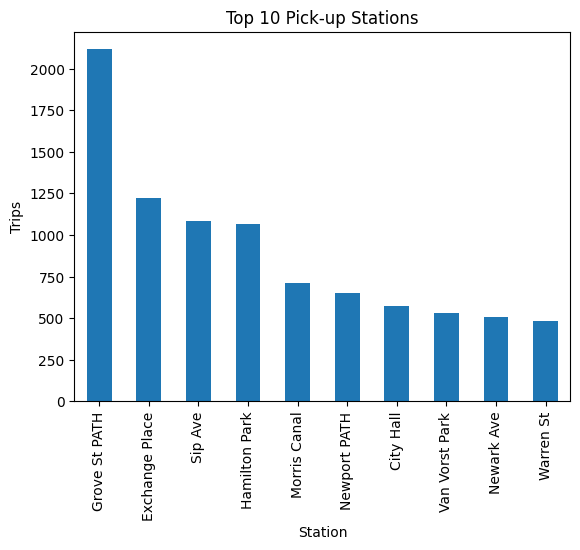

In [19]:
import matplotlib.pyplot as plt

popular_pickups = df['Start Station Name'].value_counts()
popular_pickups.head(10).plot(kind='bar')
plt.title("Top 10 Pick-up Stations")
plt.xlabel("Station")
plt.ylabel("Trips")
plt.show()

5.Does user age impact the average bike trip duration?